# ใบงานที่ 3: Regression & Classification — Model Comparison
#### Dataset : ทำนายอายุ (Age Prediction) และจำแนกเพศ (Gender Classification) จากภาพใบหน้า ด้วย UTKFace Dataset

วิชา Machine Learning



---

**เนื้อหาในไฟล์นี้ : **
- LAB 1: Regression (Simple & Multiple Linear Regression, Age Prediction)
- LAB 2: Classification (Logistic Regression, Gender Prediction, Confusion Matrix)
- LAB 3: Model Comparison (เปรียบเทียบผลลัพธ์ทั้งหมด พร้อม Metrics)


## Setup & Import Libraries

In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
)

np.random.seed(42)
%matplotlib inline

## โหลดและสำรวจข้อมูล (Load & Explore UTKFace Dataset)

**เกี่ยวกับ UTKFace:** เป็นชุดข้อมูลภาพใบหน้ากว่า 20,000 ภาพ โดยชื่อไฟล์แต่ละภาพเข้ารหัส label ไว้ในรูปแบบ:

```
[age]_[gender]_[race]_[date&time].jpg
```

- `age` : อายุ (0-116) — ใช้เป็น target สำหรับ **Regression**
- `gender` : เพศ (0 = ชาย, 1 = หญิง) — ใช้เป็น target สำหรับ **Classification**
- `race` : เชื้อชาติ (ไม่ใช้ในใบงานนี้)

**วิธีเตรียมข้อมูล:**
1. ดาวน์โหลด UTKFace จาก Kaggle: https://www.kaggle.com/datasets/jangedoo/utkface-new (โฟลเดอร์ `UTKFace` หรือ `crop_part1`)
   หรือจากเว็บทางการ: https://susanqq.github.io/UTKFace/
2. แตกไฟล์แล้ววางโฟลเดอร์ภาพไว้ใน path เดียวกับไฟล์ notebook นี้ แล้วแก้ตัวแปร `DATA_DIR` ด้านล่างให้ตรงกับ path 


In [26]:
DATA_DIR = "Dataset/UTKFace"

image_files = [f for f in os.listdir(DATA_DIR) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
print(f"พบภาพทั้งหมด {len(image_files)} ภาพ")

พบภาพทั้งหมด 23708 ภาพ


In [24]:
def parse_utkface_filename(filename):
    """แยกค่า age และ gender จากชื่อไฟล์รูปแบบ [age]_[gender]_[race]_[timestamp].jpg"""
    parts = filename.split("_")
    try:
        age = int(parts[0])
        gender = int(parts[1])
        return age, gender
    except (ValueError, IndexError):
        return None, None

records = []
for fname in image_files:
    age, gender = parse_utkface_filename(fname)
    if age is not None and gender is not None:
        records.append({"filename": fname, "age": age, "gender": gender})

df = pd.DataFrame(records)
print(f"ภาพที่แปลง label ได้สำเร็จ: {len(df)} ภาพ")
df.head()

ภาพที่แปลง label ได้สำเร็จ: 23708 ภาพ


,filename,age,gender
0,100_0_0_20170112213500903.jpg.chip.jpg,100,0
1,100_0_0_20170112215240346.jpg.chip.jpg,100,0
2,100_1_0_20170110183726390.jpg.chip.jpg,100,1
3,100_1_0_20170112213001988.jpg.chip.jpg,100,1
4,100_1_0_20170112213303693.jpg.chip.jpg,100,1


In [ ]:
# สำรวจการกระจายตัวของ label
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["age"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("การกระจายตัวของอายุ (Age Distribution)")
axes[0].set_xlabel("อายุ")
axes[0].set_ylabel("จำนวนภาพ")

gender_counts = df["gender"].value_counts().sort_index()
axes[1].bar(["ชาย (0)", "หญิง (1)"], gender_counts.values, color=["#4C72B0", "#DD8452"])
axes[1].set_title("จำนวนภาพแยกตามเพศ (Gender Distribution)")
axes[1].set_ylabel("จำนวนภาพ")

plt.tight_layout()
plt.show()

In [ ]:
# แสดงตัวอย่างภาพพร้อม label
sample_df = df.sample(6, random_state=42)
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for ax, (_, row) in zip(axes, sample_df.iterrows()):
    img = Image.open(os.path.join(DATA_DIR, row["filename"]))
    ax.imshow(img)
    gender_label = "หญิง" if row["gender"] == 1 else "ชาย"
    ax.set_title(f"อายุ {row['age']}\n{gender_label}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## เตรียมข้อมูลสำหรับสร้างแบบจำลอง (Data Preprocessing)

แปลงภาพให้มีขนาดเท่ากัน แปลงเป็น grayscale เพื่อลดจำนวนมิติเบื้องต้น แล้ว flatten เป็นเวกเตอร์ pixel เพื่อใช้เป็น Feature

> หมายเหตุ: ถ้าข้อมูลมีจำนวนมาก (20,000+ ภาพ) และเครื่องมีทรัพยากรจำกัด สามารถสุ่มตัวอย่างบางส่วน (เช่น `N_SAMPLES`) มาใช้ฝึกโมเดลก่อนเพื่อความรวดเร็ว

In [4]:
IMG_SIZE = 32          # ย่อภาพให้เหลือ 32x32 พิกเซล เพื่อไม่ให้ feature เยอะเกินไป
N_SAMPLES = None       # ใส่ตัวเลข เช่น 5000 ถ้าต้องการสุ่มใช้ข้อมูลบางส่วน (None = ใช้ทั้งหมด)

data_df = df if N_SAMPLES is None else df.sample(N_SAMPLES, random_state=42).reset_index(drop=True)

def load_and_flatten(filename):
    img = Image.open(os.path.join(DATA_DIR, filename)).convert("L")  # grayscale
    img = img.resize((IMG_SIZE, IMG_SIZE))
    return np.asarray(img, dtype=np.float32).flatten() / 255.0       # normalize 0-1

X = np.stack([load_and_flatten(f) for f in data_df["filename"]])
y_age = data_df["age"].values
y_gender = data_df["gender"].values

print("ขนาดของ Feature matrix X:", X.shape)
print("ขนาดของ y_age:", y_age.shape, " | ขนาดของ y_gender:", y_gender.shape)

ขนาดของ Feature matrix X: (23708, 1024)
ขนาดของ y_age: (23708,)  | ขนาดของ y_gender: (23708,)


##  ลดจำนวนคุณลักษณะด้วย Principal Component Analysis (PCA)

ภาพขนาด 32x32 มี feature ถึง 1,024 มิติ ซึ่งเยอะเกินไปสำหรับ Linear/Logistic Regression แบบพื้นฐาน
จึงใช้ PCA ลดจำนวนมิติ โดยยังคงความแปรปรวน (variance) ของข้อมูลไว้ในระดับที่เหมาะสม

C:\Users\user\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3588

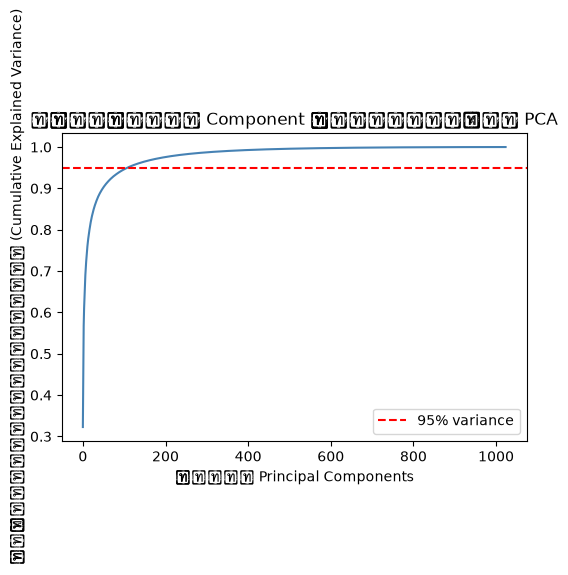

จำนวน component ที่อธิบายความแปรปรวนได้ >= 95%: 109


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA().fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(6, 4))
plt.plot(cum_var, color="steelblue")
plt.axhline(0.95, color="red", linestyle="--", label="95% variance")
plt.xlabel("จำนวน Principal Components")
plt.ylabel("สัดส่วนความแปรปรวนสะสม (Cumulative Explained Variance)")
plt.title("เลือกจำนวน Component ที่เหมาะสมด้วย PCA")
plt.legend()
plt.show()

N_COMPONENTS = int(np.argmax(cum_var >= 0.95) + 1)
N_COMPONENTS = max(N_COMPONENTS, 2)  # ต้องมีอย่างน้อย 2 component ไว้ใช้วาด Decision Boundary
print(f"จำนวน component ที่อธิบายความแปรปรวนได้ >= 95%: {N_COMPONENTS}")

In [7]:
pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("ขนาดของ X หลังลดมิติด้วย PCA:", X_pca.shape)

ขนาดของ X หลังลดมิติด้วย PCA: (23708, 109)


## แบ่งข้อมูล Train / Test

แบ่งข้อมูลชุดเดียวกัน (index เดียวกัน) สำหรับทั้งงาน Regression (ทำนายอายุ) และ Classification (จำแนกเพศ)
เพื่อให้เปรียบเทียบผลลัพธ์ระหว่าง 2 งาน

In [8]:
X_train, X_test, y_age_train, y_age_test, y_gender_train, y_gender_test = train_test_split(
    X_pca, y_age, y_gender, test_size=0.2, random_state=42
)

print("Train set:", X_train.shape[0], "ภาพ")
print("Test set :", X_test.shape[0], "ภาพ")

Train set: 18966 ภาพ
Test set : 4742 ภาพ


---
## LAB 1: Regression — ทำนายอายุจากภาพใบหน้า

### 1.1 Simple Linear Regression
ใช้ feature เดียว คือ Principal Component ที่ 1 (PC1) เท่านั้น ในการทำนายอายุ

In [9]:
X_train_simple = X_train[:, [0]]   # ใช้ PC1 เพียง feature เดียว
X_test_simple = X_test[:, [0]]

simple_lr = LinearRegression()
simple_lr.fit(X_train_simple, y_age_train)

age_pred_simple_train = simple_lr.predict(X_train_simple)
age_pred_simple_test = simple_lr.predict(X_test_simple)

print("Simple Linear Regression (PC1 only)")
print("Train R^2:", r2_score(y_age_train, age_pred_simple_train))
print("Test  R^2:", r2_score(y_age_test, age_pred_simple_test))

Simple Linear Regression (PC1 only)
Train R^2: 0.02406388521194458
Test  R^2: 0.026102721691131592


### 1.2 Multiple Linear Regression
ใช้ Principal Component ทั้งหมด (ทุกมิติหลังทำ PCA) ในการทำนายอายุ

In [11]:
multi_lr = LinearRegression()
multi_lr.fit(X_train, y_age_train)

age_pred_multi_train = multi_lr.predict(X_train)
age_pred_multi_test = multi_lr.predict(X_test)

print("Multiple Linear Regression (all PCA components)")
print("Train R^2:", r2_score(y_age_train, age_pred_multi_train))
print("Test  R^2:", r2_score(y_age_test, age_pred_multi_test))

Multiple Linear Regression (all PCA components)
Train R^2: 0.43346941471099854
Test  R^2: 0.4418567419052124


C:\Users\user\AppData\Local\Temp\ipykernel_21216\2234853158.py:16: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_21216\2234853158.py:16: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_21216\2234853158.py:16: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_21216\2234853158.py:16: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_21216\2234853158.py:16: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_21216\2234853158.py:16: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing 

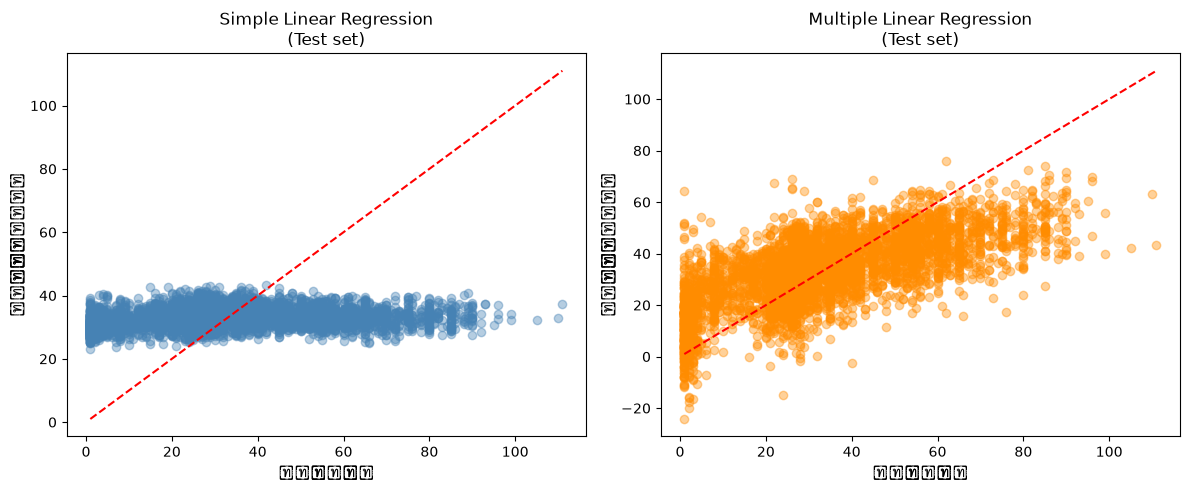

In [12]:
# ภาพเปรียบเทียบค่าอายุจริง vs ค่าที่โมเดลทำนาย (Test set)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_age_test, age_pred_simple_test, alpha=0.4, color="steelblue")
axes[0].plot([y_age_test.min(), y_age_test.max()], [y_age_test.min(), y_age_test.max()], "r--")
axes[0].set_title("Simple Linear Regression\n(Test set)")
axes[0].set_xlabel("อายุจริง")
axes[0].set_ylabel("อายุที่ทำนาย")

axes[1].scatter(y_age_test, age_pred_multi_test, alpha=0.4, color="darkorange")
axes[1].plot([y_age_test.min(), y_age_test.max()], [y_age_test.min(), y_age_test.max()], "r--")
axes[1].set_title("Multiple Linear Regression\n(Test set)")
axes[1].set_xlabel("อายุจริง")
axes[1].set_ylabel("อายุที่ทำนาย")

plt.tight_layout()
plt.show()

---
## LAB 2: Classification — จำแนกเพศจากภาพใบหน้า

### 2.1 เตรียมข้อมูลสำหรับ Classification
ใช้ feature ชุดเดียวกันกับ Regression (X_pca ที่แบ่ง train/test ไว้แล้ว) โดยเปลี่ยน target เป็น `y_gender`

In [13]:
print("สัดส่วนเพศใน Train set:")
print(pd.Series(y_gender_train).value_counts(normalize=True))
print("\nสัดส่วนเพศใน Test set:")
print(pd.Series(y_gender_test).value_counts(normalize=True))

สัดส่วนเพศใน Train set:
0    0.522303
1    0.477697
Name: proportion, dtype: float64

สัดส่วนเพศใน Test set:
0    0.52404
1    0.47596
Name: proportion, dtype: float64


### 2.2 Decision Boundary Visualization
เพื่อให้มองเห็น decision boundary ได้ ใช้เพียง 2 principal component แรก (PC1, PC2) ในการฝึกโมเดลและวาดกราฟ

C:\Users\user\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3594 (\N{THAI CHARACTER CHO CHANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 

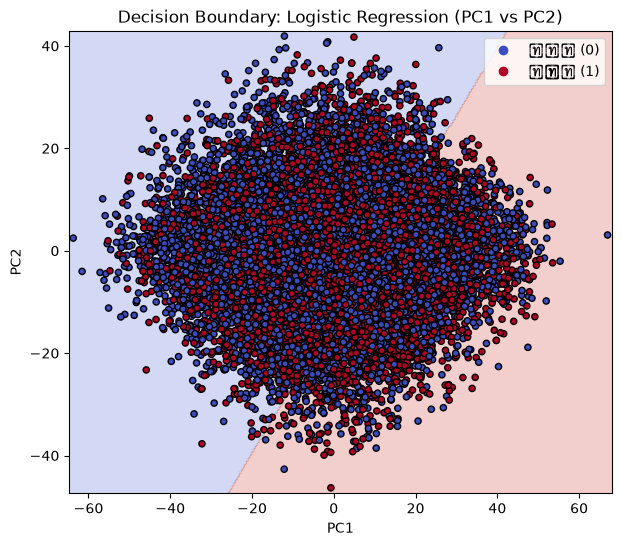

In [14]:
X_train_2d = X_train[:, :2]

boundary_lr = LogisticRegression(max_iter=1000)
boundary_lr.fit(X_train_2d, y_gender_train)

x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = boundary_lr.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7, 6))
plt.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
scatter = plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_gender_train, cmap="coolwarm", edgecolor="k", s=20)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Decision Boundary: Logistic Regression (PC1 vs PC2)")
plt.legend(handles=scatter.legend_elements()[0], labels=["ชาย (0)", "หญิง (1)"])
plt.show()

### 2.3 Logistic Regression (ใช้ Feature ทั้งหมดหลัง PCA)

In [15]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_gender_train)

gender_pred_train = log_reg.predict(X_train)
gender_pred_test = log_reg.predict(X_test)
gender_proba_test = log_reg.predict_proba(X_test)[:, 1]

print("Train Accuracy:", accuracy_score(y_gender_train, gender_pred_train))
print("Test  Accuracy:", accuracy_score(y_gender_test, gender_pred_test))

Train Accuracy: 0.8419276600231994
Test  Accuracy: 0.8388865457612822


### 2.4 Confusion Matrix

C:\Users\user\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3594 (\N{THAI CHARACTER CHO CHANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 

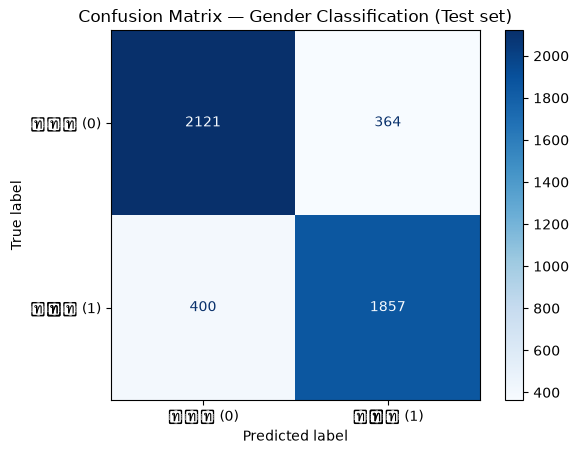

In [16]:
cm = confusion_matrix(y_gender_test, gender_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ชาย (0)", "หญิง (1)"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Gender Classification (Test set)")
plt.show()

---
## LAB 3: Model Comparison

### 3.1 Simple vs Multiple Linear Regression

In [17]:
reg_comparison = pd.DataFrame({
    "Model": ["Simple Linear Regression", "Multiple Linear Regression"],
    "Train MAE": [
        mean_absolute_error(y_age_train, age_pred_simple_train),
        mean_absolute_error(y_age_train, age_pred_multi_train),
    ],
    "Test MAE": [
        mean_absolute_error(y_age_test, age_pred_simple_test),
        mean_absolute_error(y_age_test, age_pred_multi_test),
    ],
    "Train MSE": [
        mean_squared_error(y_age_train, age_pred_simple_train),
        mean_squared_error(y_age_train, age_pred_multi_train),
    ],
    "Test MSE": [
        mean_squared_error(y_age_test, age_pred_simple_test),
        mean_squared_error(y_age_test, age_pred_multi_test),
    ],
    "Train R2": [
        r2_score(y_age_train, age_pred_simple_train),
        r2_score(y_age_train, age_pred_multi_train),
    ],
    "Test R2": [
        r2_score(y_age_test, age_pred_simple_test),
        r2_score(y_age_test, age_pred_multi_test),
    ],
})
reg_comparison

,Model,Train MAE,Test MAE,Train MSE,Test MSE,Train R2,Test R2
0,Simple Linear Regression,15.215417,15.248643,385.540344,386.551971,0.024064,0.026103
1,Multiple Linear Regression,11.536981,11.518863,223.806015,221.534027,0.433469,0.441857


### 3.2 Training vs Testing Performance (ตรวจสอบ Overfitting)

C:\Users\user\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3611 (\N{THAI CHARACTER PO PLA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3610

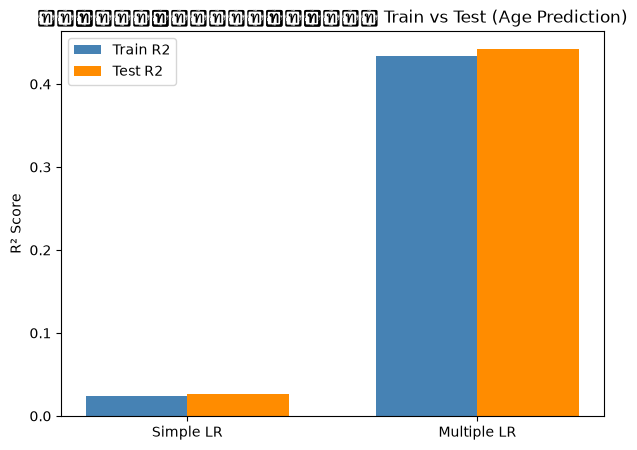

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
x_labels = ["Simple LR", "Multiple LR"]
train_r2 = reg_comparison["Train R2"].values
test_r2 = reg_comparison["Test R2"].values

x_pos = np.arange(len(x_labels))
width = 0.35
ax.bar(x_pos - width/2, train_r2, width, label="Train R2", color="steelblue")
ax.bar(x_pos + width/2, test_r2, width, label="Test R2", color="darkorange")
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_ylabel("R² Score")
ax.set_title("เปรียบเทียบประสิทธิภาพ Train vs Test (Age Prediction)")
ax.legend()
plt.show()

### 3.3 Regression vs Classification: Model Performance Metrics

สรุปตัวชี้วัดของทั้งสองงาน — Regression (ทำนายอายุ) ใช้ MAE / MSE / R², Classification (จำแนกเพศ) ใช้ Accuracy / Precision / Recall / F1 / AUC

In [19]:
clf_metrics = {
    "Accuracy": accuracy_score(y_gender_test, gender_pred_test),
    "Precision": precision_score(y_gender_test, gender_pred_test),
    "Recall": recall_score(y_gender_test, gender_pred_test),
    "F1-score": f1_score(y_gender_test, gender_pred_test),
    "AUC": roc_auc_score(y_gender_test, gender_proba_test),
}

print("=== Classification Metrics (Gender Prediction, Test set) ===")
for k, v in clf_metrics.items():
    print(f"{k}: {v:.4f}")

print("\n=== Regression Metrics (Age Prediction, Test set — Multiple LR) ===")
print(f"MAE: {mean_absolute_error(y_age_test, age_pred_multi_test):.4f}")
print(f"MSE: {mean_squared_error(y_age_test, age_pred_multi_test):.4f}")
print(f"R2 : {r2_score(y_age_test, age_pred_multi_test):.4f}")

=== Classification Metrics (Gender Prediction, Test set) ===
Accuracy: 0.8389
Precision: 0.8361
Recall: 0.8228
F1-score: 0.8294
AUC: 0.9149

=== Regression Metrics (Age Prediction, Test set — Multiple LR) ===
MAE: 11.5189
MSE: 221.5340
R2 : 0.4419


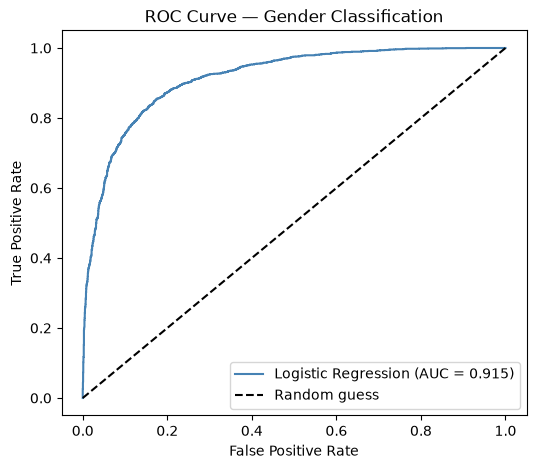

In [20]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_gender_test, gender_proba_test)
auc_val = roc_auc_score(y_gender_test, gender_proba_test)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="steelblue", label=f"Logistic Regression (AUC = {auc_val:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Gender Classification")
plt.legend()
plt.show()

### 3.4 ตารางสรุปเปรียบเทียบทั้งหมด

In [21]:
summary_table = pd.DataFrame({
    "งาน (Task)": ["Age Prediction (Simple LR)", "Age Prediction (Multiple LR)", "Gender Classification (Logistic Regression)"],
    "ประเภท (Type)": ["Regression", "Regression", "Classification"],
    "Metric หลัก": ["R2 / MAE", "R2 / MAE", "Accuracy / F1 / AUC"],
    "Train Score": [
        f"R2={reg_comparison.loc[0,'Train R2']:.3f}",
        f"R2={reg_comparison.loc[1,'Train R2']:.3f}",
        f"Acc={accuracy_score(y_gender_train, gender_pred_train):.3f}",
    ],
    "Test Score": [
        f"R2={reg_comparison.loc[0,'Test R2']:.3f}",
        f"R2={reg_comparison.loc[1,'Test R2']:.3f}",
        f"Acc={clf_metrics['Accuracy']:.3f}",
    ],
})
summary_table

,งาน (Task),ประเภท (Type),Metric หลัก,Train Score,Test Score
0,Age Prediction (Simple LR),Regression,R2 / MAE,R2=0.024,R2=0.026
1,Age Prediction (Multiple LR),Regression,R2 / MAE,R2=0.433,R2=0.442
2,Gender Classification (Logistic Regression),Classification,Accuracy / F1 / AUC,Acc=0.842,Acc=0.839
